# Defining Mode Sources and Monitors in BEAMZ

This notebook mirrors the Tidy3D `ModalSourcesMonitors.ipynb` example with the local `beamz-1/matplotlib` implementation. We launch the fundamental mode of a silicon waveguide, record fields on monitor planes, decompose the output into guided modes, and then repeat the calculation for a width-step junction.

The implementation is intentionally close to the original tutorial, but uses BEAMZ concepts:

- `ModeSource` computes a guided mode on the source plane and injects it into the FDTD grid.
- `Monitor` objects accumulate frequency-domain DFT fields on transverse planes.
- `PortSpec` tells BEAMZ how to project those monitor fields onto forward and backward waveguide modes.
- `Simulation.get_S_matrix_modal_dft(...)` returns modal amplitudes and normalized power spectra.

Current BEAMZ note: this notebook uses multifrequency `ModeSource` profiles and the same straight-guide raw-flux normalization used by the Tidy3D example for the junction mode-decomposition plot.


## Setup

The notebook imports BEAMZ from the sibling `beamz-1` checkout when that directory is present, so it uses the local `matplotlib` branch rather than an installed package from elsewhere.


In [1]:
from pathlib import Path
import inspect
import sys

local_beamz = None
for candidate in (
    Path.cwd().resolve().parent / "beamz-1",
    Path.cwd().resolve().parent.parent / "beamz-1",
):
    if (candidate / "beamz").is_dir():
        local_beamz = candidate.resolve()
        break
if local_beamz is None:
    raise RuntimeError("Could not find local BEAMZ checkout at ../beamz-1 or ../../beamz-1")
sys.path = [str(local_beamz)] + [p for p in sys.path if p and Path(p).resolve() != local_beamz]
for name in list(sys.modules):
    if name == "beamz" or name.startswith("beamz."):
        del sys.modules[name]

import beamz
from beamz.simulation.core import Simulation
print(f"Using local BEAMZ checkout: {local_beamz}")
print(beamz.__file__)
print(inspect.getfile(Simulation))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from beamz import (
    LIGHT_SPEED,
    PML,
    Design,
    Material,
    ModeSource,
    Monitor,
    PortSpec,
    Rectangle,
    Simulation,
    calc_optimal_fdtd_params,
    plot_tidy3d_cross_sections,
    plot_tidy3d_dft_field,
    plot_mode_fields,
    µm,
)
from beamz.devices.sources.signals import gaussian_band_pulse
from beamz.visual.mpl import plot_modal_dft_diagnostics

plt.rcParams.update({"figure.dpi": 120})


Using local BEAMZ checkout: /Users/quentinwach/Code/beamz-1
/Users/quentinwach/Code/beamz-1/beamz/__init__.py
/Users/quentinwach/Code/beamz-1/beamz/simulation/core.py


## Straight Waveguide Simulation

The Tidy3D example is a 3D silicon ridge waveguide on silicon dioxide. We use the same physical dimensions and place the geometry in BEAMZ's positive-coordinate design box. The FDTD mesh is deliberately coarser than the Tidy3D cloud example so it remains practical to run locally.


In [2]:
# Geometry and material parameters.
WG_HEIGHT = 0.22 * µm
WG_WIDTH = 0.45 * µm
SI_EPS = 3.48**2
SIO2_EPS = 1.45**2
AIR_EPS = 1.0
N_SI = np.sqrt(SI_EPS)
N_SIO2 = np.sqrt(SIO2_EPS)

# Optical band.
WL0 = 1.55 * µm
FREQ0 = LIGHT_SPEED / WL0
FWIDTH = FREQ0 / 10
NFREQS = 17
FREQS = np.linspace(FREQ0 - 2 * FWIDTH, FREQ0 + 2 * FWIDTH, NFREQS)
LAMBDAS_UM = LIGHT_SPEED / FREQS / µm
FCENT_IND = NFREQS // 2
SOURCE_PROFILE_FREQS = FREQS

# Source profile injection strategy. "center" uses the historical single
# center-wavelength profile; "multifrequency" uses one source profile per
# frequency in SOURCE_PROFILE_FREQS. The comparison cell below can run both.
SOURCE_PROFILE_STRATEGY = "multifrequency"
COMPARE_SOURCE_PROFILE_STRATEGIES = False
SOURCE_PROFILE_COMPARISON_STRATEGIES = ("center", "multifrequency")

# BEAMZ can project each wavelength against its own local mode basis, or reuse
# the center-frequency basis. Tidy3D-style broadband mode monitors are closest
# to the per-frequency solve, while "single" is useful as a tracking diagnostic.
MODAL_DFT_MODE_STRATEGY = "per_frequency"
COMPARE_MODAL_DFT_STRATEGIES = False

# CPML is closer to Tidy3D PML behavior, but is several times slower than the
# simple sponge absorber in this local 3D implementation. Use "sponge" for
# fast plotting iterations and "cpml" for cleaner modal diagnostics.
PML_FORMULATION = "cpml"
PML_T = 1.75 * µm
PML_CLEARANCE = 0.5 * µm

# Simulation box and modal planes. Dimensions are in meters. BEAMZ includes
# the PML in the simulation domain, so keep the original usable interior spans
# while increasing the absorber thickness.
SIM_X = 4.0 * µm + 2.0 * (PML_T + PML_CLEARANCE)
SIM_Y = 3.0 * µm + 2.0 * (PML_T + PML_CLEARANCE)
SIM_Z = 2.0 * µm + 2.0 * (PML_T + PML_CLEARANCE)
SUBSTRATE_TOP_Z = 0.5 * SIM_Z
SUBSTRATE_T = SUBSTRATE_TOP_Z
WG_Z0 = SUBSTRATE_TOP_Z
WG_CENTER_Z = WG_Z0 + 0.5 * WG_HEIGHT

SRC_X = PML_T + PML_CLEARANCE
SRC_MON_X = SRC_X + 0.25 * µm
OUT_X = SIM_X - PML_T - PML_CLEARANCE
MODE_SPAN_Y = 3.0 * µm
MODE_SPAN_Z = 2.0 * µm
DEVICE_SPAN_Y = MODE_SPAN_Y
DEVICE_SPAN_Z = MODE_SPAN_Z
if SIM_Y < DEVICE_SPAN_Y + 2.0 * (PML_T + PML_CLEARANCE) or SIM_Z < DEVICE_SPAN_Z + 2.0 * (PML_T + PML_CLEARANCE):
    raise ValueError("Simulation domain is too small for the requested PML clearance.")
SOURCE_SPAN_Y = DEVICE_SPAN_Y
SOURCE_SPAN_Z = DEVICE_SPAN_Z
MONITOR_SPAN_Y = DEVICE_SPAN_Y
MONITOR_SPAN_Z = DEVICE_SPAN_Z

# Keep this modest for local execution; increase to 10-12 for better quantitative accuracy.
POINTS_PER_WAVELENGTH = 8 # 8 is nice for fast iterations, 14 already gives us darn nice results! 20 for perfect match
POLARIZATION = "te"
FIELD_COMPONENT = "Ey" if POLARIZATION == "te" else "Ez"
DISPLAY_FIELD_COMPONENT = FIELD_COMPONENT
DX, DT = calc_optimal_fdtd_params(
    WL0,
    N_SI,
    dims=3,
    safety_factor=0.999,
    points_per_wavelength=POINTS_PER_WAVELENGTH,
    width=SIM_X,
    height=SIM_Y,
    depth=SIM_Z,
)

print(f"dx = {DX/µm:.3f} um, dt = {DT*1e18:.2f} as")
print(f"grid shape approximately: {SIM_X/DX:.0f} x {SIM_Y/DX:.0f} x {SIM_Z/DX:.0f}")


dx = 0.056 um, dt = 107.11 as
grid shape approximately: 108 x 90 x 72


## Build the Structures

The straight guide is silicon on a silica substrate with air above. A second helper adds the wider output section used later for the mode-conversion junction.


In [3]:
def straight_waveguide_design():
    design = Design(
        width=SIM_X,
        height=SIM_Y,
        depth=SIM_Z,
        material=Material(AIR_EPS),
    )
    design += Rectangle(
        position=(0.0, 0.0, 0.0),
        width=SIM_X,
        height=SIM_Y,
        depth=SUBSTRATE_T,
        material=Material(SIO2_EPS),
    )
    design += Rectangle(
        position=(0.0, 0.5 * SIM_Y - 0.5 * WG_WIDTH, WG_Z0),
        width=SIM_X,
        height=WG_WIDTH,
        depth=WG_HEIGHT,
        material=Material(SI_EPS),
    )
    return design


def junction_design(wgout_width=1.4 * µm):
    design = straight_waveguide_design()
    design += Rectangle(
        position=(0.5 * SIM_X, 0.5 * SIM_Y - 0.5 * wgout_width, WG_Z0),
        width=0.5 * SIM_X,
        height=wgout_width,
        depth=WG_HEIGHT,
        material=Material(SI_EPS),
    )
    return design


design = straight_waveguide_design()
grid = design.rasterize(resolution=DX)


● Done: Raster cache hit (3d): 7e30472632fae0bda30f816dd0044a7d8d3fbfa68c0778d2facf7d606693bac1.npz | load=0.03s


## Source and Monitor Helpers

BEAMZ modal S-parameter extraction uses ordinary DFT monitors plus `PortSpec` metadata. For a `+x` launch, BEAMZ's current port basis reports the forward-propagating output wave on the `a_minus` branch when the output `PortSpec.direction` is `+x`; the notebook helpers below keep that convention local and label the plots in physical terms.


In [4]:

def mode_window():
    y0 = 0.5 * SIM_Y - 0.5 * MODE_SPAN_Y
    y1 = 0.5 * SIM_Y + 0.5 * MODE_SPAN_Y
    z0 = WG_Z0 - 0.5 * MODE_SPAN_Z
    z1 = WG_Z0 + 0.5 * MODE_SPAN_Z
    return y0, y1, max(0.0, z0), min(SIM_Z, z1)


def device_window():
    y0 = 0.5 * SIM_Y - 0.5 * MONITOR_SPAN_Y
    y1 = 0.5 * SIM_Y + 0.5 * MONITOR_SPAN_Y
    z0 = WG_Z0 - 0.5 * MONITOR_SPAN_Z
    z1 = WG_Z0 + 0.5 * MONITOR_SPAN_Z
    return (
        max(PML_T + PML_CLEARANCE, y0),
        min(SIM_Y - PML_T - PML_CLEARANCE, y1),
        max(PML_T + PML_CLEARANCE, z0),
        min(SIM_Z - PML_T - PML_CLEARANCE, z1),
    )


def make_pulse():
    return gaussian_band_pulse(
        FREQS,
        carrier_frequency=FREQ0,
        dt=DT,
        run_after_sources_uoc=25.0,
        max_output_distance_um=(OUT_X - SRC_X) / µm,
    )


def source_profile_frequencies(strategy=None):
    strategy = SOURCE_PROFILE_STRATEGY if strategy is None else strategy
    if isinstance(strategy, str):
        key = strategy.lower()
        if key in {"center", "single", "single_frequency", "none"}:
            return None
        if key in {"multifrequency", "multi", "per_frequency", "per-frequency"}:
            return np.asarray(SOURCE_PROFILE_FREQS, dtype=float)
        raise ValueError(f"Unknown source profile strategy: {strategy!r}")
    if strategy is None:
        return None
    freqs = np.asarray(strategy, dtype=float).reshape(-1)
    return freqs if freqs.size > 1 else None


def source_profile_label(strategy=None):
    freqs = source_profile_frequencies(strategy)
    if freqs is None:
        return "center"
    return f"multifrequency ({len(freqs)} profiles)"


def make_source(grid, pulse, *, source_profile_strategy=None):
    return ModeSource(
        grid=grid,
        center=(SRC_X, 0.5 * SIM_Y, WG_Z0),
        width=SOURCE_SPAN_Y,
        height=SOURCE_SPAN_Z,
        wavelength=WL0,
        pol=POLARIZATION,
        signal=pulse.signal,
        signal_quadrature=pulse.signal_quadrature,
        profile_frequencies=source_profile_frequencies(source_profile_strategy),
        direction="+x",
    )


def dft_monitor(name, x, freqs=FREQS, record_fields=False):
    y0, y1, z0, z1 = device_window()
    return Monitor(
        start=(x, y0, z0),
        end=(x, y1, z1),
        name=name,
        record_fields=record_fields,
        accumulate_power=False,
        dft_enabled=True,
        dft_frequencies=np.asarray(freqs, dtype=float),
        dft_components=("Ex", "Ey", "Ez", "Hx", "Hy", "Hz"),
        dft_window="none",
        dft_record_every_step=True,
    )


def field_monitor(name="field"):
    return Monitor(
        start=(0.0, 0.0, WG_CENTER_Z),
        end=(SIM_X, SIM_Y, WG_CENTER_Z),
        name=name,
        record_fields=False,
        accumulate_power=False,
        dft_enabled=True,
        dft_frequencies=np.asarray([FREQ0], dtype=float),
        dft_components=(FIELD_COMPONENT,),
        dft_window="none",
        dft_record_every_step=True,
    )


def build_simulation(design, *, source_profile_strategy=None):
    grid = design.rasterize(resolution=DX)
    pulse = make_pulse()
    source = make_source(grid, pulse, source_profile_strategy=source_profile_strategy)
    monitors = [
        dft_monitor("src_ref", SRC_X),
        dft_monitor("src", SRC_MON_X),
        dft_monitor("out", OUT_X),
        field_monitor(),
    ]
    sim = Simulation(
        design=design,
        sources=[source],
        monitors=monitors,
        boundaries=[PML(edges="all", thickness=PML_T, formulation=PML_FORMULATION)],
        time=pulse.time,
        resolution=DX,
    )
    return sim, source, monitors, pulse


def print_monitor_flux_check(result, port="out_m0", label="", *, show_raw_flux=False):
    checks = result.get("diagnostics", {}).get("monitor_flux_checks", {})
    check = checks.get(port)
    if not check:
        return
    prefix = f"{label} " if label else ""
    flux = np.asarray(check["monitor_flux"], dtype=float)
    selected = np.asarray(check.get("P_selected", check["P_modal_sum"]), dtype=float)
    selected_net = np.asarray(check.get("P_selected_modal_net", check["P_modal_net"]), dtype=float)
    modal_sum = np.asarray(check["P_modal_sum"], dtype=float)
    branch = check.get("scattered_wave", "?")
    wave = result.get("diagnostics", {}).get("waves", {}).get(port, {})
    residual = np.asarray(wave.get("projection_residual", []), dtype=float)
    residual_e = np.asarray(wave.get("projection_residual_e", []), dtype=float)
    residual_h = np.asarray(wave.get("projection_residual_h", []), dtype=float)
    residual_balanced = np.asarray(wave.get("projection_residual_balanced", []), dtype=float)
    e_scale = np.asarray(wave.get("projection_e_scale", []), dtype=np.complex128)
    h_scale = np.asarray(wave.get("projection_h_scale", []), dtype=np.complex128)
    print(f"{prefix}{port} selected outgoing branch: {branch}")
    print(f"{prefix}{port} central selected/sum: {selected[FCENT_IND]:.4g} / {modal_sum[FCENT_IND]:.4g}")
    if residual.size == flux.size:
        print(f"{prefix}{port} central/max projection residual: {residual[FCENT_IND]:.3g} / {np.nanmax(residual):.3g}")
    if residual_e.size == flux.size and residual_h.size == flux.size and residual_balanced.size == flux.size:
        print(
            f"{prefix}{port} central E/H/balanced residual: "
            f"{residual_e[FCENT_IND]:.3g} / {residual_h[FCENT_IND]:.3g} / {residual_balanced[FCENT_IND]:.3g}"
        )
    if e_scale.size == flux.size and h_scale.size == flux.size:
        print(
            f"{prefix}{port} central |E scale|/|H scale|: "
            f"{abs(e_scale[FCENT_IND]):.3g} / {abs(h_scale[FCENT_IND]):.3g}"
        )
    if show_raw_flux:
        print(f"{prefix}{port} central raw DFT flux diagnostic: {flux[FCENT_IND]:.4g}")
        print(f"{prefix}{port} max |raw flux - selected net| diagnostic: {np.nanmax(np.abs(flux - selected_net)):.3g}")



def modal_dft_strategies():
    strategies = [MODAL_DFT_MODE_STRATEGY]
    if COMPARE_MODAL_DFT_STRATEGIES:
        for strategy in ("single", "per_frequency"):
            if strategy not in strategies:
                strategies.append(strategy)
    return strategies


def modal_output_ports(num_modes=3):
    return [f"out_m{idx}" for idx in range(num_modes)]


def compute_modal_dft_results(sim, *, num_modes=3):
    results = {}
    ports = modal_ports(num_modes=num_modes)
    outputs = ["src", *modal_output_ports(num_modes)]
    for strategy in modal_dft_strategies():
        results[strategy] = sim.get_S_matrix_modal_dft(
            source_port="src",
            ports=ports,
            output_ports=outputs,
            frequencies=FREQS,
            as_sax=False,
            return_diagnostics=True,
            min_incident_db=-50.0,
            mode_strategy=strategy,
        )
    return results, results[MODAL_DFT_MODE_STRATEGY]



def run_straight_source_profile_comparison(strategies=SOURCE_PROFILE_COMPARISON_STRATEGIES):
    comparisons = {}
    design = straight_waveguide_design()
    for strategy in strategies:
        label = source_profile_label(strategy)
        print(f"Running straight guide with source profile strategy: {label}")
        sim, source, monitors, pulse = build_simulation(design, source_profile_strategy=strategy)
        sim.run_compiled(
            progress=True,
            record_interval=max(1, sim.num_steps // 80),
            record_fields=[],
        )
        results, result = compute_modal_dft_results(sim, num_modes=3)
        powers = modal_powers(result)
        residual = modal_residual(result, port="out_m0")
        rejected = modal_rejected_fraction(result, port="out_m0")
        comparisons[str(strategy)] = {
            "label": label,
            "sim": sim,
            "source": source,
            "monitors": monitors,
            "pulse": pulse,
            "results": results,
            "result": result,
            "powers": powers,
            "residual": residual,
            "rejected": rejected,
        }
        print(
            f"  mode0 center/mean/min/max = "
            f"{powers[FCENT_IND, 0]:.4g} / {np.mean(powers[:, 0]):.4g} / "
            f"{np.min(powers[:, 0]):.4g} / {np.max(powers[:, 0]):.4g}"
        )
        if residual.size == len(FREQS):
            print(f"  residual center/max = {residual[FCENT_IND]:.3g} / {np.nanmax(residual):.3g}")
        if rejected.size == len(FREQS):
            print(
                f"  rejected branch center/mean/max = "
                f"{rejected[FCENT_IND]:.3g} / {np.nanmean(rejected):.3g} / {np.nanmax(rejected):.3g}"
            )
    return comparisons


def plot_source_profile_comparison(comparisons):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True)
    for data in comparisons.values():
        label = data["label"]
        axes[0].plot(LAMBDAS_UM, data["powers"][:, 0], marker="o", ms=3, label=label)
        residual = np.asarray(data["residual"], dtype=float)
        if residual.size == len(FREQS):
            axes[1].plot(LAMBDAS_UM, residual, marker="o", ms=3, label=label)
        rejected = np.asarray(data["rejected"], dtype=float)
        if rejected.size == len(FREQS):
            axes[2].plot(LAMBDAS_UM, rejected, marker="o", ms=3, label=label)
    axes[0].set_title("Mode 0 selected outgoing")
    axes[0].set_ylabel("Power in mode (W)")
    axes[1].set_title("Projection residual")
    axes[1].set_ylabel("Relative residual")
    axes[2].set_title("Rejected branch")
    axes[2].set_ylabel("Fraction of incident")
    for ax in axes:
        ax.set_xlim([LAMBDAS_UM[-1], LAMBDAS_UM[0]])
        ax.set_xlabel("Wavelength (um)")
        ax.legend()
    fig.suptitle("Straight guide source profile injection comparison")
    fig.tight_layout()
    return fig, axes


def modal_powers(result, num_modes=3):
    s_matrix = result["s_matrix"]
    return np.vstack([np.abs(s_matrix[(f"out_m{i}", "src")]) ** 2 for i in range(num_modes)]).T


def modal_rejected_fraction(result, port="out_m0"):
    diag = result["diagnostics"]
    rejected = np.asarray(diag["monitor_flux_checks"][port].get("P_rejected", []), dtype=float)
    p_in = np.asarray(diag["P_in"], dtype=float)
    if rejected.size != p_in.size:
        return np.full_like(p_in, np.nan, dtype=float)
    return rejected / np.maximum(p_in, 1e-18)


def modal_residual(result, port="out_m0"):
    return np.asarray(result["diagnostics"]["waves"][port].get("projection_residual", []), dtype=float)


def print_strategy_summary(results, label, port="out_m0"):
    print(f"{label} absorber: {PML_FORMULATION}")
    for strategy, result in results.items():
        powers = modal_powers(result)
        residual = modal_residual(result, port=port)
        rejected = modal_rejected_fraction(result, port=port)
        jagged = np.sqrt(np.mean(np.diff(powers[:, 0], 2) ** 2))
        print(
            f"  {strategy}: mode0 center/mean/min/max = "
            f"{powers[FCENT_IND, 0]:.4g} / {np.mean(powers[:, 0]):.4g} / "
            f"{np.min(powers[:, 0]):.4g} / {np.max(powers[:, 0]):.4g}; "
            f"jagged = {jagged:.4g}"
        )
        if residual.size == len(FREQS):
            print(f"    residual center/max = {residual[FCENT_IND]:.3g} / {np.nanmax(residual):.3g}")
        if rejected.size == len(FREQS):
            print(f"    rejected branch center/mean/max = {rejected[FCENT_IND]:.3g} / {np.nanmean(rejected):.3g} / {np.nanmax(rejected):.3g}")


def plot_strategy_comparison(results, title, port="out_m0"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharex=True)
    for strategy, result in results.items():
        powers = modal_powers(result)
        residual = modal_residual(result, port=port)
        axes[0].plot(LAMBDAS_UM, powers[:, 0], marker="o", ms=3, label=strategy)
        if residual.size == len(FREQS):
            axes[1].plot(LAMBDAS_UM, residual, marker="o", ms=3, label=strategy)
    axes[0].set_title("Mode 0 selected outgoing power")
    axes[0].set_ylabel("Power in mode (W)")
    axes[1].set_title("Projection residual")
    axes[1].set_ylabel("Relative residual")
    for ax in axes:
        ax.set_xlim([LAMBDAS_UM[-1], LAMBDAS_UM[0]])
        ax.set_xlabel("Wavelength (um)")
        ax.legend()
    fig.suptitle(title)
    fig.tight_layout()
    return fig, axes


def modal_probe_ports(monitor_name, *, num_modes=3, prefix=None):
    prefix = prefix or monitor_name
    return [
        PortSpec(
            name=f"{prefix}_m{idx}",
            monitor_name=monitor_name,
            direction="+x",
            polarization=POLARIZATION,
            mode_index=idx,
            incident_wave="plus",
            scattered_wave="minus",
        )
        for idx in range(num_modes)
    ]


def modal_projection_probe(sim, monitor_name, incident_power, *, label, num_modes=3):
    ports = modal_probe_ports(monitor_name, num_modes=num_modes, prefix=label.lower().replace(" ", "_"))
    waves = sim.extract_port_waves_dft(
        ports=ports,
        frequencies=FREQS,
        return_power=True,
        mode_strategy=MODAL_DFT_MODE_STRATEGY,
    )
    pin = np.asarray(incident_power, dtype=float)
    selected = np.vstack([
        np.abs(waves[port.name]["a_minus"]) ** 2 / np.maximum(pin, 1e-18)
        for port in ports
    ]).T
    rejected = np.vstack([
        np.abs(waves[port.name]["a_plus"]) ** 2 / np.maximum(pin, 1e-18)
        for port in ports
    ]).T
    residual = np.asarray(waves[ports[0].name].get("projection_residual", []), dtype=float)
    print(
        f"{label} probe: mode0 center/mean/min/max = "
        f"{selected[FCENT_IND, 0]:.4g} / {np.mean(selected[:, 0]):.4g} / "
        f"{np.min(selected[:, 0]):.4g} / {np.max(selected[:, 0]):.4g}"
    )
    if residual.size == len(FREQS):
        print(f"{label} probe: residual center/max = {residual[FCENT_IND]:.3g} / {np.nanmax(residual):.3g}")
    print(
        f"{label} probe: rejected branch center/mean/max = "
        f"{rejected[FCENT_IND, 0]:.3g} / {np.mean(rejected[:, 0]):.3g} / {np.max(rejected[:, 0]):.3g}"
    )
    return {
        "selected": selected,
        "rejected": rejected,
        "residual": residual,
        "waves": waves,
    }


def plot_probe_comparison(probes, *, title="Straight guide projection probes"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharex=True)
    for label, probe in probes.items():
        axes[0].plot(LAMBDAS_UM, probe["selected"][:, 0], marker="o", ms=3, label=label)
        residual = np.asarray(probe["residual"], dtype=float)
        if residual.size == len(FREQS):
            axes[1].plot(LAMBDAS_UM, residual, marker="o", ms=3, label=label)
    axes[0].set_title("Mode 0 selected outgoing power")
    axes[0].set_ylabel("Power / source incident")
    axes[1].set_title("Projection residual")
    axes[1].set_ylabel("Relative residual")
    for ax in axes:
        ax.set_xlim([LAMBDAS_UM[-1], LAMBDAS_UM[0]])
        ax.set_xlabel("Wavelength (um)")
        ax.legend()
    fig.suptitle(title)
    fig.tight_layout()
    return fig, axes

def modal_ports(num_modes=3):
    ports = [
        PortSpec(
            name="src",
            monitor_name="src",
            reference_monitor="src_ref",
            direction="+x",
            polarization=POLARIZATION,
            mode_index=0,
            incident_wave="auto",
            scattered_wave="auto",
        )
    ]
    ports.extend(
        PortSpec(
            name=f"out_m{idx}",
            monitor_name="out",
            direction="+x",
            polarization=POLARIZATION,
            mode_index=idx,
            incident_wave="plus",
            scattered_wave="minus",
        )
        for idx in range(num_modes)
    )
    return ports


def plot_origin():
    return (0.5 * SIM_X, 0.5 * SIM_Y, WG_Z0)


def mode_markers(*, source=False):
    y0, y1, z0, z1 = device_window()
    sy0 = 0.5 * SIM_Y - 0.5 * SOURCE_SPAN_Y
    sy1 = 0.5 * SIM_Y + 0.5 * SOURCE_SPAN_Y
    sz0 = max(PML_T + PML_CLEARANCE, WG_Z0 - 0.5 * SOURCE_SPAN_Z)
    sz1 = min(SIM_Z - PML_T - PML_CLEARANCE, WG_Z0 + 0.5 * SOURCE_SPAN_Z)
    source_x = SRC_X / µm - 0.5 * SIM_X / µm
    out_x = OUT_X / µm - 0.5 * SIM_X / µm
    xy_span = (y0 / µm - 0.5 * SIM_Y / µm, y1 / µm - 0.5 * SIM_Y / µm)
    xz_span = (z0 / µm - WG_Z0 / µm, z1 / µm - WG_Z0 / µm)
    source_xy_span = (sy0 / µm - 0.5 * SIM_Y / µm, sy1 / µm - 0.5 * SIM_Y / µm)
    source_xz_span = (sz0 / µm - WG_Z0 / µm, sz1 / µm - WG_Z0 / µm)
    out_xy = {"x": out_x, "span": xy_span, "color": "#f4a51c"}
    out_xz = {"x": out_x, "span": xz_span, "color": "#f4a51c"}
    if not source:
        return [out_xy], [out_xz]
    src_xy = {"x": source_x, "span": source_xy_span, "color": "#66bb6a", "arrow": True, "arrow_y": 0.0}
    src_xz = {"x": source_x, "span": source_xz_span, "color": "#66bb6a", "arrow": True, "arrow_y": 0.0}
    return [src_xy, out_xy], [src_xz, out_xz]


def plot_setup(grid, *, junction=False, source=False):
    xy_markers, xz_markers = mode_markers(source=source)
    return plot_tidy3d_cross_sections(
        grid,
        z=WG_Z0,
        y=0.5 * SIM_Y,
        origin=plot_origin(),
        substrate_z=WG_Z0,
        core_permittivity=SI_EPS,
        substrate_permittivity=SIO2_EPS,
        pml_thickness=PML_T,
        xy_markers=xy_markers,
        xz_markers=xz_markers,
        width_ratios=[1, 1.4] if junction else None,
        xlim=(-0.5 * SIM_X / µm, 0.5 * SIM_X / µm),
        ylim=(-0.5 * SIM_Y / µm, 0.5 * SIM_Y / µm),
        zlim=(-0.5 * SIM_Z / µm, 0.5 * SIM_Z / µm),
        show=False,
    )



def source_mode_dataframe(grid, num_modes=3):
    from beamz.devices.sources.solve import solve_modes

    eps = np.asarray(grid.permittivity)
    x_index = int(np.clip(round(SRC_X / DX), 0, eps.shape[2] - 1))
    eps_profile = eps[:, :, x_index]
    neffs, e_fields, _h_fields, _ = solve_modes(
        eps=eps_profile,
        omega=2.0 * np.pi * FREQ0,
        dL=DX,
        m=int(num_modes),
        direction="-x",
        filter_pol=None,
        target_neff=0.98 * N_SI,
        return_fields=True,
    )

    y0, y1, z0, z1 = mode_window()
    iy0 = int(np.clip(np.floor(y0 / DX), 0, eps_profile.shape[1] - 1))
    iy1 = int(np.clip(np.ceil(y1 / DX), iy0 + 1, eps_profile.shape[1]))
    iz0 = int(np.clip(np.floor(z0 / DX), 0, eps_profile.shape[0] - 1))
    iz1 = int(np.clip(np.ceil(z1 / DX), iz0 + 1, eps_profile.shape[0]))
    core = eps_profile[iz0:iz1, iy0:iy1] > 0.5 * (SIO2_EPS + SI_EPS)

    display_ey_component = 1
    display_ez_component = 2

    rows = []
    lambda_um = WL0 / µm
    lambda_cm = WL0 * 100.0
    for mode_index in range(int(num_modes)):
        ey = np.squeeze(np.asarray(e_fields[mode_index, display_ey_component]))[iz0:iz1, iy0:iy1]
        ez = np.squeeze(np.asarray(e_fields[mode_index, display_ez_component]))[iz0:iz1, iy0:iy1]
        intensity_te = np.abs(ey) ** 2
        intensity_tm = np.abs(ez) ** 2
        intensity = intensity_te + intensity_tm
        total_te = float(np.sum(intensity_te))
        total_tm = float(np.sum(intensity_tm))
        total = max(total_te + total_tm, 1e-30)
        core_te = float(np.sum(intensity_te[core]))
        core_tm = float(np.sum(intensity_tm[core]))
        neff = complex(neffs[mode_index])
        k_eff = max(float(np.imag(neff)), 0.0)
        loss_db_cm = 0.0 if k_eff == 0.0 else (4.0 * np.pi * k_eff / lambda_cm) * (10.0 / np.log(10.0))
        mode_area_um2 = ((float(np.sum(intensity)) * (DX / µm) ** 2) ** 2) / max(
            float(np.sum(intensity**2)) * (DX / µm) ** 2,
            1e-30,
        )
        rows.append(
            {
                "wavelength": lambda_um,
                "n eff": float(np.real(neff)),
                "k eff": k_eff,
                "loss (dB/cm)": loss_db_cm,
                "TE (Ey) fraction": total_te / total,
                "wg TE fraction": core_te / max(total_te, 1e-30),
                "wg TM fraction": core_tm / max(total_tm, 1e-30),
                "mode area": mode_area_um2,
            }
        )

    index = pd.MultiIndex.from_product(
        [[FREQ0], range(int(num_modes))],
        names=["f", "mode_index"],
    )
    return pd.DataFrame(rows, index=index)


def plot_source_modes(grid, num_modes=3):
    return plot_mode_fields(
        grid,
        plane_x=SRC_X,
        wavelength=WL0,
        polarization=None,
        num_modes=num_modes,
        window=mode_window(),
        origin=plot_origin(),
        direction="-x",
        target_neff=0.98 * N_SI,
        show=False,
    )


## Visualize the Setup and Source Mode

The first plot shows the simulation layout. Then we initialize the `ModeSource` explicitly and plot the modal field components used by this branch. For this asymmetric ridge in the current BEAMZ branch, `pol="tm"` selects the confined silicon guided mode; `pol="te"` tends to select a substrate-like branch.


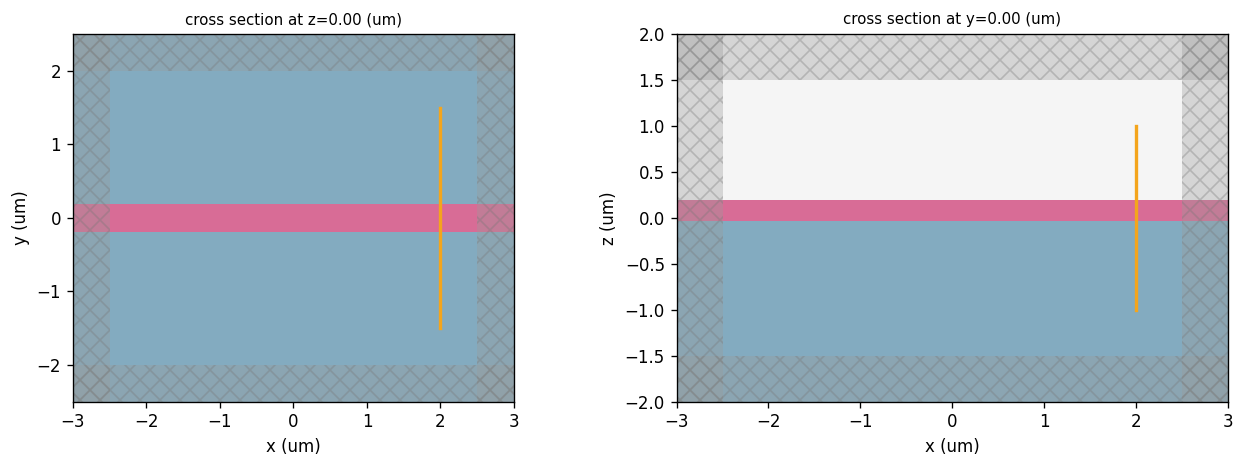

Selected source effective index: 2.2724
Mode effective indices: [2.27237335 1.59439268 1.42709489]


wavelength     n eff         k eff  loss (dB/cm)  \
f            mode_index                                                     
1.934145e+14 0                 1.55  2.272373  0.000000e+00  0.000000e+00   
             1                 1.55  1.594393  0.000000e+00  0.000000e+00   
             2                 1.55  1.427095  5.559293e-17  1.957411e-11   

                         TE (Ey) fraction  wg TE fraction  wg TM fraction  \
f            mode_index                                                     
1.934145e+14 0                   0.961566        0.640327        0.017284   
             1                   0.075603        0.070792        0.115106   
             2                   0.007290        0.041201        0.008011   

                         mode area  
f            mode_index             
1.934145e+14 0            0.150191  
             1            0.378284  
             2            1.863900

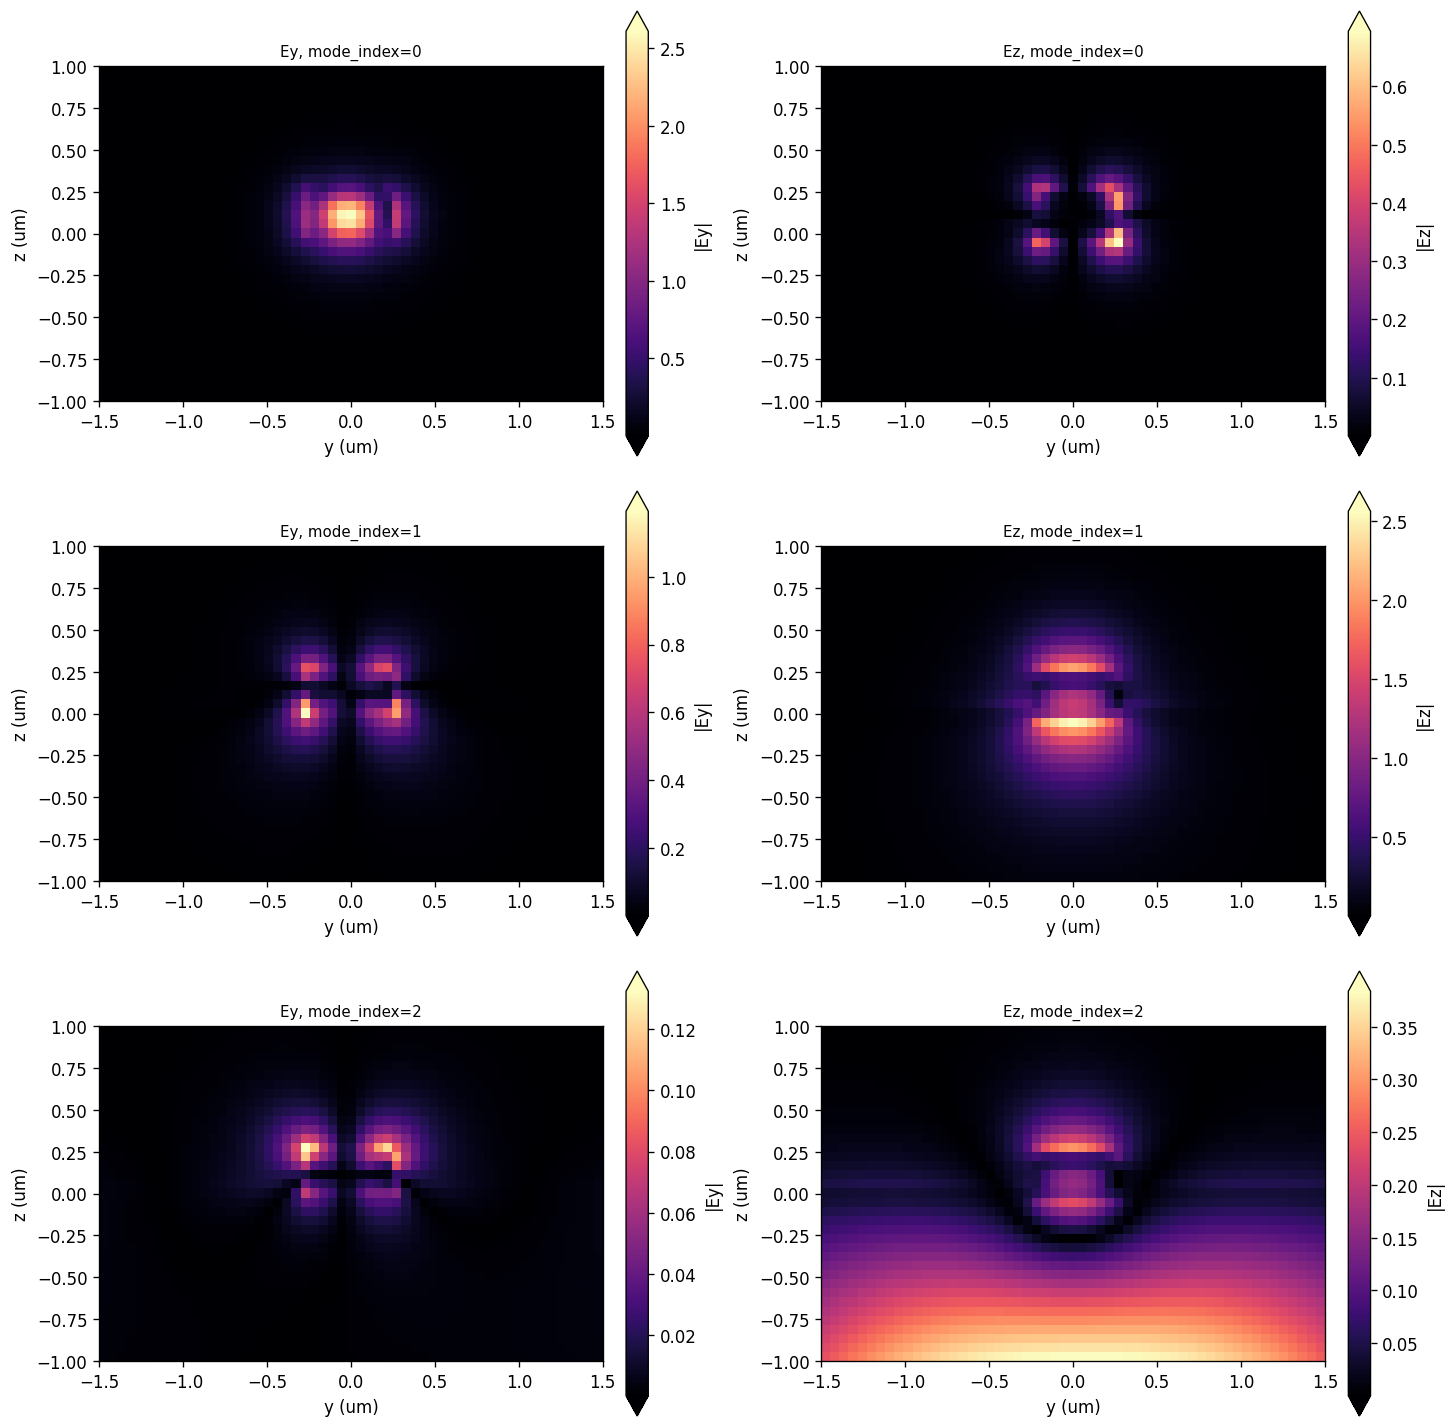

In [5]:
sim_preview, source_preview, monitors_preview, pulse_preview = build_simulation(design)
fig, axes = plot_setup(grid, source=False)
plt.show()

source_preview.initialize(grid.permittivity, DX, dt=DT)
print(f"Selected source effective index: {np.real(source_preview._neff):.4f}")

fig, axes, source_neffs = plot_source_modes(grid, num_modes=3)
print("Mode effective indices:", np.real(source_neffs))
source_mode_table = source_mode_dataframe(grid, num_modes=3)
display(source_mode_table)
plt.show()


## Run the Straight Waveguide

The run accumulates DFT fields on the source/reference and output planes. A separate in-plane DFT field monitor mirrors Tidy3D's `FieldMonitor` for the frequency-domain field plot.


In [6]:
RUN_SIMULATIONS = True

straight_result = None
straight_results = {}
if RUN_SIMULATIONS:
    sim_straight, source_straight, monitors_straight, pulse_straight = build_simulation(
        straight_waveguide_design(),
        source_profile_strategy=SOURCE_PROFILE_STRATEGY,
    )
    straight_run = sim_straight.run_compiled(
        progress=True,
        record_interval=max(1, sim_straight.num_steps // 80),
        record_fields=[FIELD_COMPONENT],
    )
    print(f"completed {sim_straight.current_step} FDTD steps")
    print("ModeSource profile strategy:", source_profile_label(SOURCE_PROFILE_STRATEGY))

    straight_results, straight_result = compute_modal_dft_results(sim_straight, num_modes=3)
else:
    print("Set RUN_SIMULATIONS = True to run the local FDTD solve.")


● Done: Raster cache hit (3d): 7e30472632fae0bda30f816dd0044a7d8d3fbfa68c0778d2facf7d606693bac1.npz | load=0.14s
● JIT compiling v0.3 packed FDTD program... done!
● Progress: 100% (11826/11826 steps)
completed 11826 FDTD steps
ModeSource profile strategy: multifrequency (17 profiles)


## In-Plane Fields

The original Tidy3D notebook plots the real part of the frequency-domain `Ey` field from an in-plane `FieldMonitor`. Here we use the matching BEAMZ DFT field monitor on the horizontal plane through the waveguide center, displayed with the Tidy3D-equivalent `Ey` label for the selected BEAMZ guided branch.


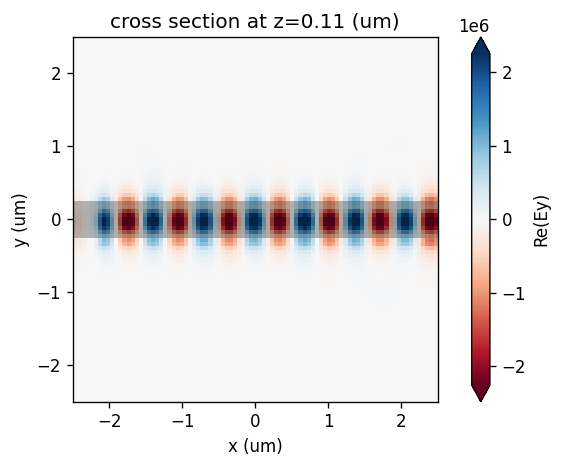

In [7]:
if RUN_SIMULATIONS:
    field_monitor_straight = next(m for m in sim_straight.monitors if m.name == "field")
    fig, ax = plot_tidy3d_dft_field(
        sim_straight,
        field_monitor_straight,
        field=FIELD_COMPONENT,
        display_field=DISPLAY_FIELD_COMPONENT,
        frequency=FREQ0,
        val="real",
        origin=plot_origin(),
        core_permittivity=SI_EPS,
        cmap="RdBu",
        xlim=(-2.5, 2.5),
        ylim=(-2.5, 2.5),
        show=False,
    )
    plt.show()


## Mode Monitor Decomposition

For the output monitor, BEAMZ solves local waveguide modes on the monitor cross-section and computes complex amplitudes for both propagation branches. The modal power in each branch is $|a|^2$ after normalization by the source port incident amplitude.


Straight absorber: cpml
  per_frequency: mode0 center/mean/min/max = 0.9996 / 0.9944 / 0.9688 / 1.015; jagged = 0.005661
    residual center/max = 0.202 / 0.236
    rejected branch center/mean/max = 0.00958 / 0.009 / 0.0173
Modal DFT mode strategy: per_frequency
Raw DFT flux diagnostic at central frequency: 0.00149118241918599
Straight out_m0 selected outgoing branch: minus
Straight out_m0 central selected/sum: 1.083 / 1.093
Straight out_m0 central/max projection residual: 0.202 / 0.236
Straight out_m0 central E/H/balanced residual: 0.202 / 0.169 / 0.2
Straight out_m0 central |E scale|/|H scale|: 1 / 0.988
Power distribution at central frequency in first three modes
  selected outgoing  [9.99586366e-01 3.64515033e-04 7.27863617e-04]
  rejected branch    [9.57998025e-03 2.89918647e-08 2.66873617e-04]


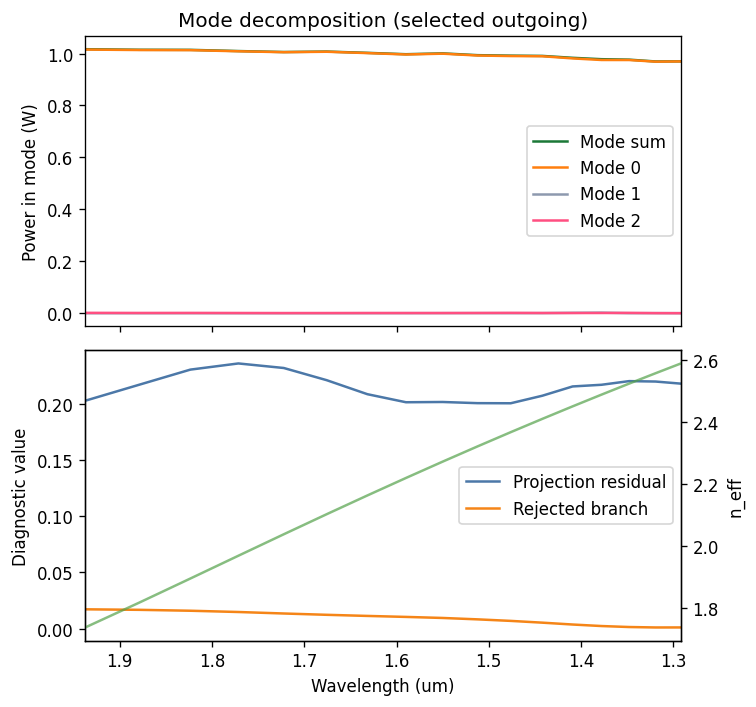

Straight near source probe: mode0 center/mean/min/max = 0.9965 / 0.999 / 0.991 / 1.005
Straight near source probe: residual center/max = 0.183 / 0.224
Straight near source probe: rejected branch center/mean/max = 0.00764 / 0.00919 / 0.0192
Straight output probe: mode0 center/mean/min/max = 0.9996 / 0.9944 / 0.9688 / 1.015
Straight output probe: residual center/max = 0.202 / 0.236
Straight output probe: rejected branch center/mean/max = 0.00958 / 0.009 / 0.0173


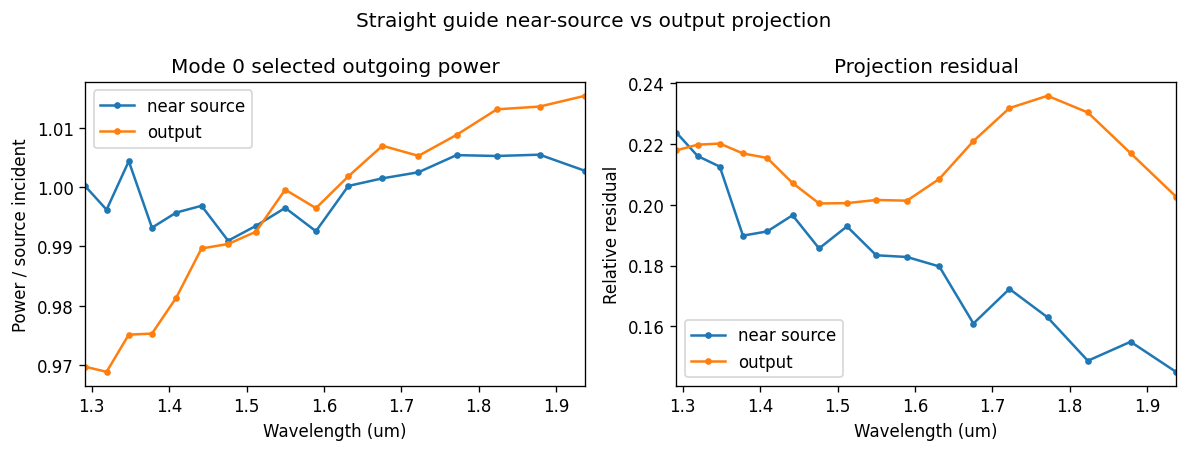

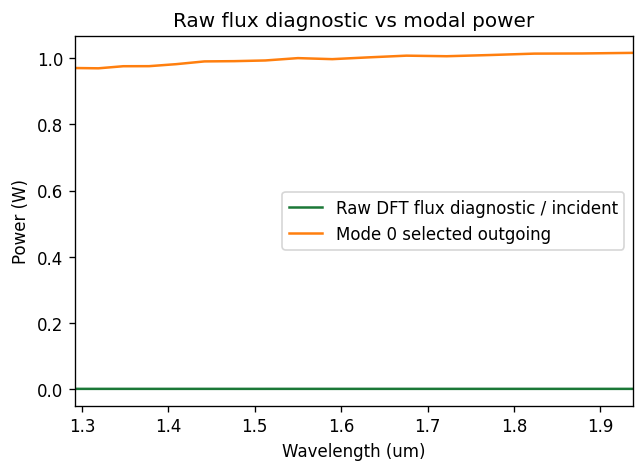

In [8]:
if RUN_SIMULATIONS:
    s_straight = straight_result["s_matrix"]
    diag_straight = straight_result["diagnostics"]
    flux_straight = np.asarray(next(m for m in monitors_straight if m.name == "out").get_dft_flux(), dtype=float)
    pin_straight = np.asarray(diag_straight["P_in"], dtype=float)
    flux_straight_norm = flux_straight / np.maximum(pin_straight, 1e-18)

    forward_power = modal_powers(straight_result)
    waves = diag_straight["waves"]
    src_incident = np.sqrt(np.maximum(pin_straight, 1e-18))
    backward_raw = np.vstack([np.abs(waves[f"out_m{i}"]["a_plus"] / src_incident) ** 2 for i in range(3)]).T

    print_strategy_summary(straight_results, "Straight")
    print("Modal DFT mode strategy:", diag_straight.get("mode_strategy"))
    print("Raw DFT flux diagnostic at central frequency:", flux_straight_norm[FCENT_IND])
    print_monitor_flux_check(straight_result, port="out_m0", label="Straight")
    print("Power distribution at central frequency in first three modes")
    print("  selected outgoing ", forward_power[FCENT_IND])
    print("  rejected branch   ", backward_raw[FCENT_IND])

    plot_modal_dft_diagnostics(
        straight_result,
        output_ports=modal_output_ports(3),
        title="Mode decomposition (selected outgoing)",
        residual_port="out_m0",
        show=True,
    )

    if COMPARE_MODAL_DFT_STRATEGIES:
        plot_strategy_comparison(straight_results, "Straight guide modal strategy comparison")
        plt.show()

    near_source_probe = modal_projection_probe(
        sim_straight,
        "src",
        pin_straight,
        label="Straight near source",
        num_modes=3,
    )
    output_probe = modal_projection_probe(
        sim_straight,
        "out",
        pin_straight,
        label="Straight output",
        num_modes=3,
    )
    plot_probe_comparison(
        {"near source": near_source_probe, "output": output_probe},
        title="Straight guide near-source vs output projection",
    )
    plt.show()

    fig, ax = plt.subplots(1, figsize=(6, 4))
    ax.plot(LAMBDAS_UM, flux_straight_norm, color="#1b7837", label="Raw DFT flux diagnostic / incident")
    ax.plot(LAMBDAS_UM, forward_power[:, 0], color="#ff7f0e", label="Mode 0 selected outgoing")
    ax.set_xlim([LAMBDAS_UM[-1], LAMBDAS_UM[0]])
    ax.set_xlabel("Wavelength (um)")
    ax.set_ylabel("Power (W)")
    ax.set_title("Raw flux diagnostic vs modal power")
    ax.legend()
    plt.show()


In [9]:
source_profile_comparisons = None
if RUN_SIMULATIONS and COMPARE_SOURCE_PROFILE_STRATEGIES:
    source_profile_comparisons = run_straight_source_profile_comparison()
    plot_source_profile_comparison(source_profile_comparisons)
    plt.show()
else:
    print("Set COMPARE_SOURCE_PROFILE_STRATEGIES = True to run center vs multifrequency source-profile comparison.")


Set COMPARE_SOURCE_PROFILE_STRATEGIES = True to run center vs multifrequency source-profile comparison.


## Waveguide Junction with Straight-Guide Normalization

Next we reproduce the Tidy3D width-step example by adding a wider silicon guide in the second half of the domain. The output guide is multimode, so the modal monitor quantifies how much power remains in the fundamental mode and how much transfers to higher-order modes.


● Done: Raster cache hit (3d): 4ac3a3afd27061d921fa9ec5bf132f7dc3d403e9de8ea170e7d31a10837c89f0.npz | load=0.13s


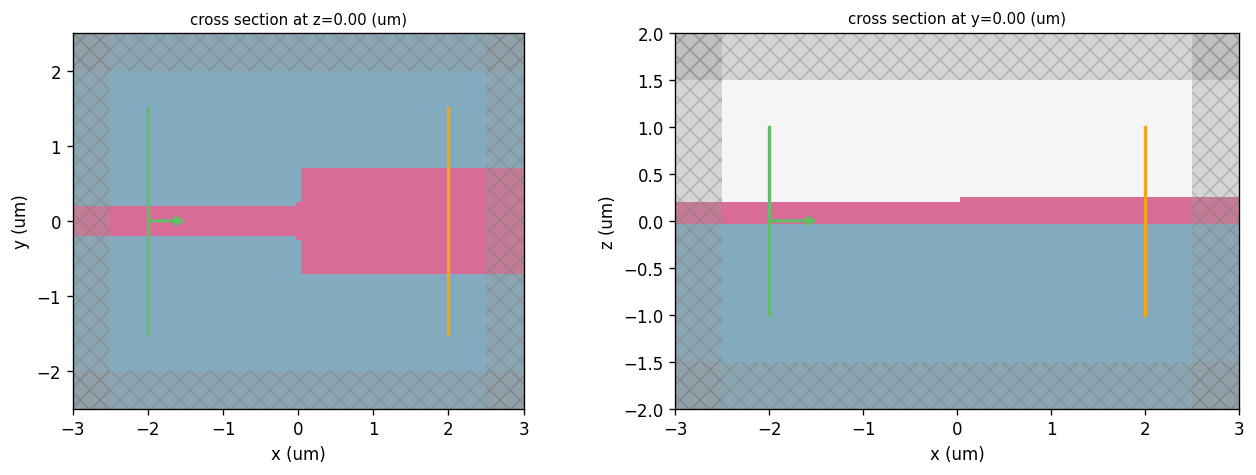

In [10]:
design_junction = junction_design(wgout_width=1.4 * µm)
grid_junction = design_junction.rasterize(resolution=DX)
fig, axes = plot_setup(grid_junction, junction=True, source=True)
plt.show()


In [11]:
junction_result = None
junction_results = {}
if RUN_SIMULATIONS:
    sim_jct, source_jct, monitors_jct, pulse_jct = build_simulation(
        design_junction,
        source_profile_strategy=SOURCE_PROFILE_STRATEGY,
    )
    junction_run = sim_jct.run_compiled(progress=True, record_fields=[])
    print(f"completed {sim_jct.current_step} FDTD steps")
    print("ModeSource profile strategy:", source_profile_label(SOURCE_PROFILE_STRATEGY))

    junction_results, junction_result = compute_modal_dft_results(sim_jct, num_modes=3)


● JIT compiling v0.3 packed FDTD program... done!
● Progress: 100% (11826/11826 steps)
completed 11826 FDTD steps
ModeSource profile strategy: multifrequency (17 profiles)


## Junction In-Plane Fields

As in the straight-waveguide case, plot the real part of the frequency-domain in-plane field on the horizontal plane through the silicon core before decomposing the output into modes.


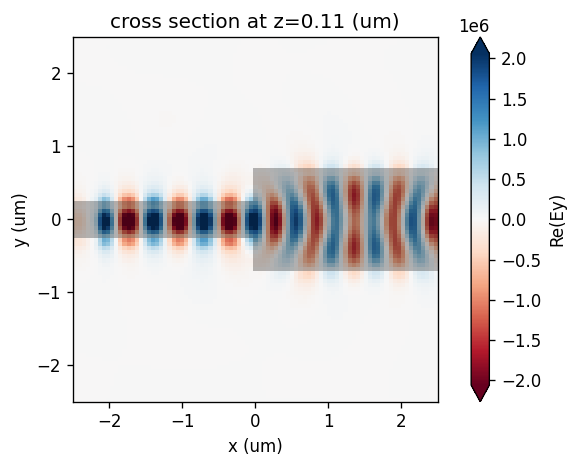

In [12]:
if RUN_SIMULATIONS:
    field_monitor_jct = next(m for m in sim_jct.monitors if m.name == "field")
    fig, ax = plot_tidy3d_dft_field(
        sim_jct,
        field_monitor_jct,
        field=FIELD_COMPONENT,
        display_field=DISPLAY_FIELD_COMPONENT,
        frequency=FREQ0,
        val="real",
        origin=plot_origin(),
        core_permittivity=SI_EPS,
        cmap="RdBu",
        xlim=(-2.5, 2.5),
        ylim=(-2.5, 2.5),
        show=False,
    )
    plt.show()


Tidy-style raw/flux normalization max |delta vs S-matrix normalization|: 582.4999831925958
Junction absorber: cpml
  per_frequency: mode0 center/mean/min/max = 0.7628 / 0.7766 / 0.6928 / 0.8898; jagged = 0.04142
    residual center/max = 0.227 / 0.295
    rejected branch center/mean/max = 0.000973 / 0.00286 / 0.0084
Modal DFT mode strategy: per_frequency
Junction out_m0 selected outgoing branch: minus
Junction out_m0 central selected/sum: 0.8368 / 0.8378
Junction out_m0 central/max projection residual: 0.227 / 0.295
Junction out_m0 central E/H/balanced residual: 0.227 / 0.175 / 0.227
Junction out_m0 central |E scale|/|H scale|: 1.01 / 0.996


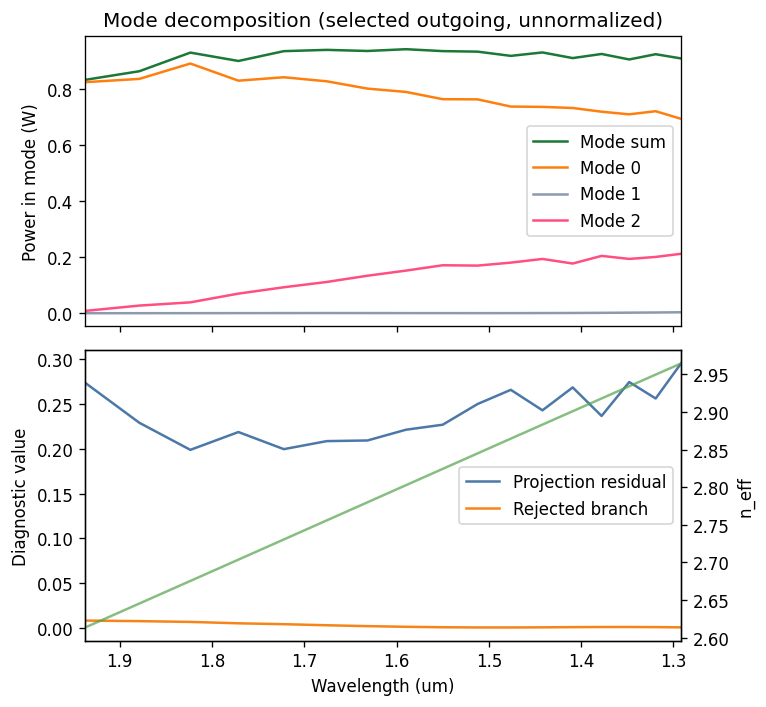

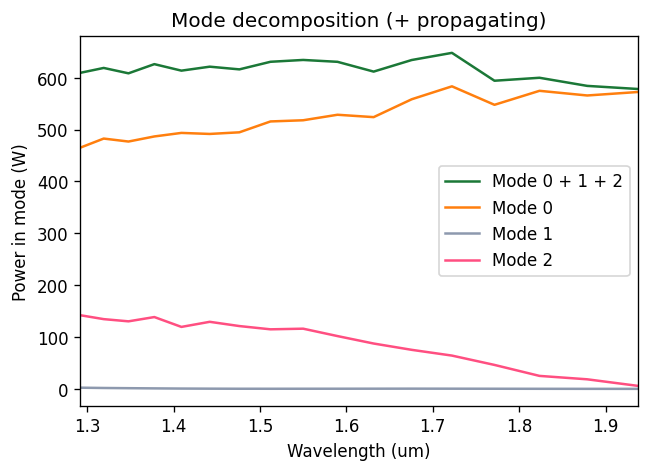

In [13]:
if RUN_SIMULATIONS:
    s_jct = junction_result["s_matrix"]
    jct_forward_power = modal_powers(junction_result)
    jct_waves = junction_result["diagnostics"]["waves"]
    jct_forward_power_raw = np.vstack(
        [np.abs(jct_waves[f"out_m{idx}"]["a_minus"]) ** 2 for idx in range(3)]
    ).T

    # Match the Tidy3D notebook: raw junction mode-monitor amplitudes normalized by
    # the straight-waveguide flux monitor, not by the already-normalized S matrix.
    straight_flux_reference = np.maximum(np.asarray(flux_straight, dtype=float), 1e-18)
    jct_forward_power_norm = jct_forward_power_raw / straight_flux_reference[:, None]
    s_matrix_norm = jct_forward_power / np.maximum(forward_power[:, 0], 1e-18)[:, None]
    print(
        "Tidy-style raw/flux normalization max |delta vs S-matrix normalization|:",
        np.nanmax(np.abs(jct_forward_power_norm - s_matrix_norm)),
    )
    print_strategy_summary(junction_results, "Junction")
    print("Modal DFT mode strategy:", junction_result["diagnostics"].get("mode_strategy"))
    print_monitor_flux_check(junction_result, port="out_m0", label="Junction")

    plot_modal_dft_diagnostics(
        junction_result,
        output_ports=modal_output_ports(3),
        title="Mode decomposition (selected outgoing, unnormalized)",
        residual_port="out_m0",
        show=True,
    )

    if COMPARE_MODAL_DFT_STRATEGIES:
        plot_strategy_comparison(junction_results, "Junction modal strategy comparison")
        plt.show()

    fig, ax = plt.subplots(1, figsize=(6, 4))
    ax.plot(LAMBDAS_UM, np.sum(jct_forward_power_norm, axis=1), color="#1b7837", label="Mode 0 + 1 + 2")
    mode_colors = ["#ff7f0e", "#8d99ae", "#ff4f81"]
    for idx in range(3):
        ax.plot(LAMBDAS_UM, jct_forward_power_norm[:, idx], color=mode_colors[idx], label=f"Mode {idx}")
    ax.set_xlabel("Wavelength (um)")
    ax.set_xlim([LAMBDAS_UM[-1], LAMBDAS_UM[0]])
    ax.set_ylabel("Power in mode (W)")
    ax.set_title("Mode decomposition (+ propagating)")
    ax.legend()
    plt.show()


## Broadband Source and Projection Diagnostics

Tidy3D's broadband mode source can approximate the modal profile at multiple frequencies. In this local BEAMZ branch, `ModeSource` still injects one center-wavelength modal profile, so broadband agreement must be judged with the strategy comparison and projection residual plots above. `per_frequency` mode monitors are the closest analogue to Tidy3D's broadband mode monitor; `single` is kept as a diagnostic for mode-tracking artifacts.


In [14]:
print("BEAMZ ModeSource launch profile wavelength:", WL0 / µm, "um")
print("DFT wavelength span:", float(np.min(LAMBDAS_UM)), "to", float(np.max(LAMBDAS_UM)), "um")
print("Modal DFT strategies computed:", modal_dft_strategies())
print("PML formulation:", PML_FORMULATION)


BEAMZ ModeSource launch profile wavelength: 1.55 um
DFT wavelength span: 1.2916666666666667 to 1.9375000000000002 um
Modal DFT strategies computed: ['per_frequency']
PML formulation: cpml


## Summary

This notebook reproduces the core of the Tidy3D mode-source and mode-monitor example in BEAMZ:

1. Build a 3D silicon-on-silica straight waveguide.
2. Launch the fundamental guided mode with `ModeSource`.
3. Accumulate DFT fields on monitor planes.
4. Project those fields onto local waveguide modes with `PortSpec` and `get_S_matrix_modal_dft`.
5. Use a straight-waveguide normalization run to analyze mode conversion in a wider output waveguide.
